In [1]:
! pip install pandas numpy lifelines matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from lifelines import CoxPHFitter
import warnings
warnings.filterwarnings("ignore")

print("All packages loaded successfully.")

All packages loaded successfully.


# Load your data

In [3]:
# the data is structured as such:
#
#   sample_id  | relapse_free_time | relapse_free_event | TSLP | BIRC5 | S100B | ...
#   GSM1040817 |        3.2        |          1         |  8.4 |  5.1  |  7.2  | ...
#   GSM1040818 |        5.0        |          0         |  3.1 |  4.2  |  2.1  | ...
# ----------------------------------------------------------------------------------------

# load in train datasets
deg_df = pd.read_csv("../datasets/csv_files/deg_expression_matrix_train.csv")
clinical_df= pd.read_csv("../datasets/csv_files/clinical_metadata_train.csv")
train_data = pd.read_csv("../datasets/csv_files/ml_datasets/train_data.csv")

# drop null RFS values & rename columns
train_data.dropna(inplace=True)

# make the RFS event an int
train_data['relapse_free_event'] = train_data['relapse_free_event'].astype(int)

# get gene names
gene_names = list(train_data.columns[3:])

train_data.head()

,sample_name,relapse_free_time,relapse_free_event,ACO1,ADAR,ADIPOQ,AGPAT2,ALDOC,ANG,ANGPT1,...,UBE2S,VAMP3,VAMP8,VAV3,VIM,VSIG4,VTCN1,WASF3,XG,ZBTB16
0,GSM1045208,3026,0,4.799942,11.395017,6.075966,6.143011,5.383726,5.904613,3.628884,...,4.844556,6.401260,9.204786,5.647802,6.964493,4.966453,7.220646,5.180080,3.151567,3.705057
1,GSM1045209,755,1,4.971609,10.864474,8.177897,7.368229,5.854996,6.582208,3.702770,...,6.627002,6.492745,8.080794,4.995820,7.585698,5.970720,5.437708,4.532965,3.383118,4.551614
2,GSM1045210,3014,0,4.555494,10.942121,6.828506,6.252349,5.317867,5.791332,3.630954,...,4.907463,6.269060,8.533085,5.194826,6.922194,5.289430,6.854089,4.636144,3.299654,4.031339
3,GSM1045211,406,1,4.668031,10.776268,5.196359,6.861987,6.408760,4.921507,3.693400,...,5.012260,6.170261,6.865168,5.039221,7.565630,5.307223,5.566723,4.642180,3.480787,4.412832
4,GSM1045212,2225,0,5.458046,11.743277,3.567575,6.902541,8.048325,5.603227,3.580604,...,7.380517,7.418157,9.662955,5.193608,8.330933,8.333481,10.065004,5.678931,3.197258,3.402715


# Univariate Cox regression loop

In [4]:
# For each immune DEG, fit a separate Cox model:
#   Hazard(t) = h0(t) * exp(β * gene_expression)
#
# The model estimates β by comparing, at each relapse time point,
# the expression of patients who relapsed vs those still at risk.
# β > 0 → HR > 1 → danger gene
# β < 0 → HR < 1 → protective gene

def run_univariate_cox(df, gene_columns, time_col="RFS.time", event_col="RFS"):
    """
    Run one Cox model per gene and collect results.

    Returns a DataFrame with: gene, beta, HR, 95% CI, p-value
    Sorted by p-value (most significant first).
    """
    results = []
    total = len(gene_columns)

    for i, gene in enumerate(gene_columns):
        # Keep only this gene + survival columns, drop missing values
        subset = df[[time_col, event_col, gene]].dropna()

        try:
            cph = CoxPHFitter()
            cph.fit(
                subset,
                duration_col=time_col,
                event_col=event_col,
                formula=gene        # single-gene model per iteration
            )

            s = cph.summary
            results.append({
                "gene":        gene,
                "beta":        round(float(s.loc[gene, "coef"]), 4),           # log(HR)
                "HR":          round(float(s.loc[gene, "exp(coef)"]), 4),      # Hazard Ratio
                "HR_lower_95": round(float(s.loc[gene, "exp(coef) lower 95%"]), 4),
                "HR_upper_95": round(float(s.loc[gene, "exp(coef) upper 95%"]), 4),
                "p_value":     round(float(s.loc[gene, "p"]), 4),
            })

        except Exception as e:
            print(f"  Skipped {gene}: {e}")

        # Progress indicator
        if (i + 1) % 20 == 0 or (i + 1) == total:
            print(f"  Processed {i+1}/{total} genes...")

    results_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
    return results_df


print("Running univariate Cox regression...\n")
all_results = run_univariate_cox(train_data, gene_names, time_col="relapse_free_time", event_col="relapse_free_event")

print("\nAll results (sorted by p-value):")
print(all_results.to_string(index=False))



Running univariate Cox regression...

  Processed 20/263 genes...
  Processed 40/263 genes...
  Processed 60/263 genes...
  Processed 80/263 genes...
  Processed 100/263 genes...
  Processed 120/263 genes...
  Processed 140/263 genes...
  Processed 160/263 genes...
  Processed 180/263 genes...
  Processed 200/263 genes...
  Processed 220/263 genes...
  Processed 240/263 genes...
  Processed 260/263 genes...
  Processed 263/263 genes...

All results (sorted by p-value):
    gene    beta     HR  HR_lower_95  HR_upper_95  p_value
   FBXL5 -0.7746 0.4609       0.3313       0.6412   0.0000
     EVL -0.4396 0.6443       0.5187       0.8002   0.0001
 POLR3GL -0.6891 0.5020       0.3484       0.7235   0.0002
   CDC20  0.4483 1.5657       1.2309       1.9916   0.0003
   KLHL5 -0.9318 0.3939       0.2293       0.6765   0.0007
   GATA3 -0.2529 0.7766       0.6697       0.9005   0.0008
    BLNK -0.3943 0.6742       0.5352       0.8492   0.0008
    SOX4  1.1479 3.1516       1.5756       6.3041   0.

# Filter significant genes (p < 0.05)

In [5]:
significant_genes = all_results[all_results["p_value"] < 0.05].copy()

print(f"{'='*55}")
print(f"Total genes tested:          {len(all_results)}")
print(f"Significant genes (p < 0.05): {len(significant_genes)}")
print(f"(Tian et al. found 19 from 134 immune DEGs)")
print(f"{'='*55}\n")
print(significant_genes.to_string(index=False))

Total genes tested:          263
Significant genes (p < 0.05): 55
(Tian et al. found 19 from 134 immune DEGs)

    gene    beta     HR  HR_lower_95  HR_upper_95  p_value
   FBXL5 -0.7746 0.4609       0.3313       0.6412   0.0000
     EVL -0.4396 0.6443       0.5187       0.8002   0.0001
 POLR3GL -0.6891 0.5020       0.3484       0.7235   0.0002
   CDC20  0.4483 1.5657       1.2309       1.9916   0.0003
   KLHL5 -0.9318 0.3939       0.2293       0.6765   0.0007
   GATA3 -0.2529 0.7766       0.6697       0.9005   0.0008
    BLNK -0.3943 0.6742       0.5352       0.8492   0.0008
    SOX4  1.1479 3.1516       1.5756       6.3041   0.0012
 RARRES3 -0.3255 0.7222       0.5930       0.8794   0.0012
   UBE2S  0.4701 1.6002       1.1969       2.1393   0.0015
   SOX11  0.2154 1.2403       1.0789       1.4259   0.0025
   HSPA2 -0.2879 0.7499       0.6213       0.9051   0.0027
   ERAP1 -1.1679 0.3110       0.1438       0.6726   0.0030
   HEBP2  0.9654 2.6258       1.3639       5.0551   0.0039
   S

# Classify genes as danger vs protective

In [6]:
# Paper Section 2.3:
#   HR > 1 → danger gene    (higher expression = higher relapse risk)
#   HR < 1 → protective gene (higher expression = lower relapse risk)

if len(significant_genes) > 0:
    significant_genes["role"] = significant_genes["HR"].apply(
        lambda hr: "danger" if hr > 1 else "protective"
    )

    danger_genes     = significant_genes[significant_genes["role"] == "danger"]["gene"].tolist()
    protective_genes = significant_genes[significant_genes["role"] == "protective"]["gene"].tolist()

    print(f"Danger genes     (HR > 1): {danger_genes}")
    print(f"Protective genes (HR < 1): {protective_genes}")
    print(f"\nExpected from paper: danger = TSLP, BIRC5, S100B, MDK, S100P")
    print(f"                     protective = RARRES3, BLNK, ACO1")
else:
    print("No significant genes found — check your data or p-value threshold.")

Danger genes     (HR > 1): ['CDC20', 'SOX4', 'UBE2S', 'SOX11', 'HEBP2', 'S100P', 'SFRP1', 'BIRC5', 'ARF1', 'UBE2E3', 'UBE2C', 'SOD2', 'SPHK1', 'MDK', 'CEBPD', 'TF', 'ALDOC', 'S100B']
Protective genes (HR < 1): ['FBXL5', 'EVL', 'POLR3GL', 'KLHL5', 'GATA3', 'BLNK', 'RARRES3', 'HSPA2', 'ERAP1', 'DEFB132', 'COLEC12', 'MICB', 'EIF4E3', 'COL1A2', 'GNS', 'PREX1', 'JAM2', 'FLNB', 'FBN1', 'FBXL16', 'CFB', 'C6orf120', 'TRIM45', 'GPAM', 'CXCL14', 'MTHFD1', 'CEBPA', 'VAV3', 'STAT5A', 'ACO1', 'DCTN6', 'MYB', 'PRLR', 'CXCL12', 'FOS', 'CLU', 'DENND1B']

Expected from paper: danger = TSLP, BIRC5, S100B, MDK, S100P
                     protective = RARRES3, BLNK, ACO1


# Forest plot (Figure 2B equivalent)

Forest plot saved as: forest_plot.png


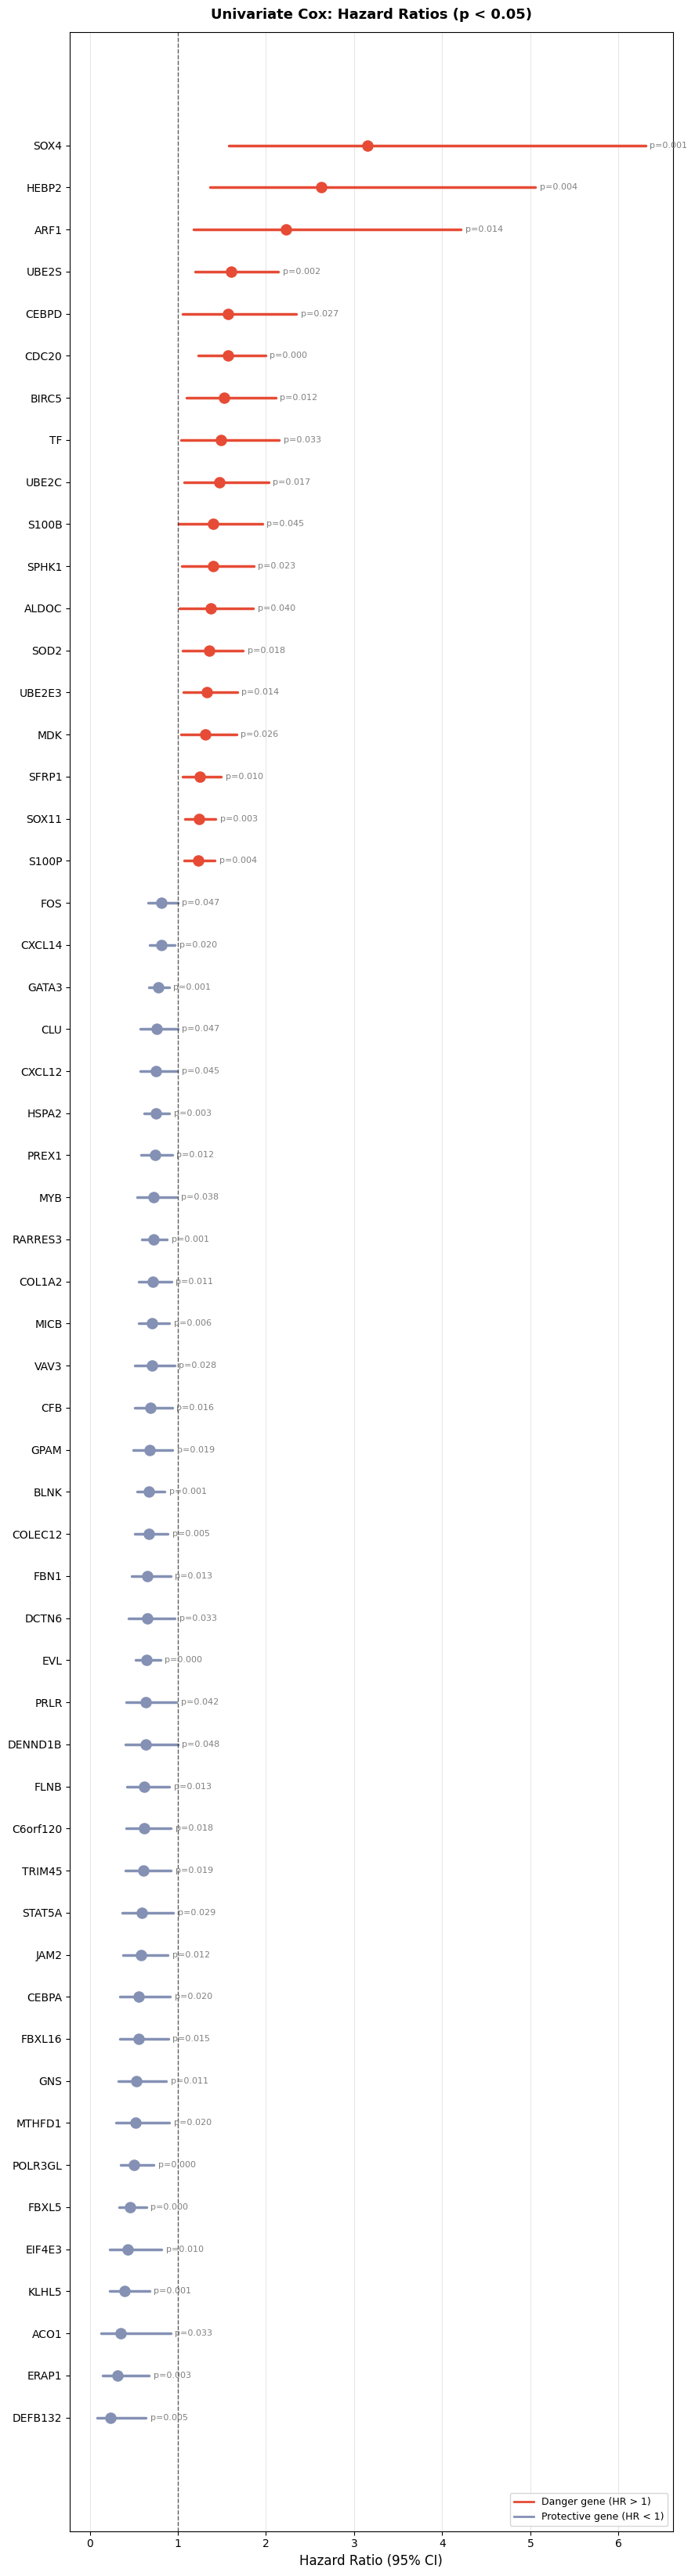

Saved files:
  univariate_cox_all_genes.csv     — full results for all genes
  univariate_cox_significant.csv   — significant genes only (p < 0.05)
  filtered_expression_matrix_train.csv   — add newly named sample_name column
  clinical_metadata_train.csv   — add newly named sample_name column

--- Next steps ---
  Step 1: Feed significant_genes['gene'] into LASSO Cox
  Step 2: Run stepwise multivariate Cox on LASSO-selected genes
  Step 3: Risk Score = sum(expression_i * beta_i)  [beta from THIS step]


In [7]:

def plot_forest(results_df, title="Univariate Cox: Hazard Ratios (p < 0.05)"):
    """
    Forest plot of HR and 95% CI for each significant gene.
    Red  = danger gene (HR > 1)
    Blue = protective gene (HR < 1)
    Dashed line at HR = 1 (no effect)
    """
    if len(results_df) == 0:
        print("No significant genes to plot.")
        return

    df_plot = results_df.sort_values("HR").reset_index(drop=True)
    colors  = ["#E64B35" if r == "danger" else "#8491B4" for r in df_plot["role"]]

    fig, ax = plt.subplots(figsize=(9, max(4, len(df_plot) * 0.6)))

    for i, row in df_plot.iterrows():
        # Confidence interval line
        ax.plot(
            [row["HR_lower_95"], row["HR_upper_95"]], [i, i],
            color=colors[i], linewidth=2.5, solid_capstyle="round"
        )
        # HR point
        ax.scatter(row["HR"], i, color=colors[i], s=90, zorder=5)
        # p-value label
        ax.text(
            row["HR_upper_95"] + 0.05, i,
            f"p={row['p_value']:.3f}",
            va="center", fontsize=8, color="grey"
        )

    # Reference line at HR = 1
    ax.axvline(x=1, color="black", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot["gene"], fontsize=10)
    ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)

    legend_elements = [
        Line2D([0], [0], color="#E64B35", lw=2, label="Danger gene (HR > 1)"),
        Line2D([0], [0], color="#8491B4", lw=2, label="Protective gene (HR < 1)")
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../visuals/forest_plot.png", dpi=150, bbox_inches="tight")
    print("Forest plot saved as: forest_plot.png")
    plt.show()


if len(significant_genes) > 0:
    plot_forest(significant_genes)


# ============================================================================
# Save results to CSV
# ============================================================================
all_results.to_csv("../datasets/csv_files/univariate_cox_all_genes_train.csv", index=False)

if len(significant_genes) > 0:
    significant_genes.to_csv("../datasets/csv_files/univariate_cox_sig_train.csv", index=False)

deg_df.to_csv("../datasets/csv_files/filtered_expression_matrix_train.csv", index=False)
clinical_df.to_csv("../datasets/csv_files/clinical_metadata_train.csv", index=False)

print("Saved files:")
print("  univariate_cox_all_genes.csv     — full results for all genes")
print("  univariate_cox_significant.csv   — significant genes only (p < 0.05)")
print("  filtered_expression_matrix_train.csv   — add newly named sample_name column")
print("  clinical_metadata_train.csv   — add newly named sample_name column")
print("\n--- Next steps ---")
print("  Step 1: Feed significant_genes['gene'] into LASSO Cox")
print("  Step 2: Run stepwise multivariate Cox on LASSO-selected genes")
print("  Step 3: Risk Score = sum(expression_i * beta_i)  [beta from THIS step]")

# Analyzing Results & Building Intuition

In [8]:
# According to paper:
# danger: TSLP, BIRC5, S100B, MDK, & S100P
# protective: RARRES3, BLNK, & ACO1

signature_genes = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]
sig_genes_results = all_results[all_results['gene'].isin(signature_genes)]
sig_genes_results

# HR > 1, danger: S100P, BIRC5, MDK, S100B, TSLP
# HR < 1, protective: BLNK, RARRES3, ACO1

# hazard ratios match!

,gene,beta,HR,HR_lower_95,HR_upper_95,p_value
6,BLNK,-0.3943,0.6742,0.5352,0.8492,0.0008
8,RARRES3,-0.3255,0.7222,0.5930,0.8794,0.0012
14,S100P,0.2078,1.2310,1.0687,1.4180,0.0040
22,BIRC5,0.4200,1.5220,1.0979,2.1100,0.0117
40,MDK,0.2716,1.3120,1.0335,1.6656,0.0257
44,ACO1,-1.0536,0.3487,0.1327,0.9163,0.0326
50,S100B,0.3396,1.4044,1.0079,1.9569,0.0448
67,TSLP,0.9445,2.5717,0.9279,7.1275,0.0694


In [9]:
# look at cox summary for one gene & understand all terms
subset = train_data[['relapse_free_time', 'relapse_free_event', 'BIRC5']].dropna()
cph = CoxPHFitter()
cph.fit(subset,
        duration_col='relapse_free_time',
        event_col='relapse_free_event',
        formula='BIRC5'
    )
cph.print_summary()

# this gene is an inhibitor of apoptosis (IAP) gene family --> high in tumors & fetuses, low in adult tissue

<lifelines.CoxPHFitter: fitted with 104 total observations, 56 right-censored observations>
             duration col = 'relapse_free_time'
                event col = 'relapse_free_event'
      baseline estimation = breslow
   number of observations = 104
number of events observed = 48
   partial log-likelihood = -203.39
         time fit was run = 2026-04-11 18:08:48 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
BIRC5      0.42      1.52      0.17            0.09            0.75                1.10                2.11

           cmp to    z    p  -log2(p)
covariate                            
BIRC5        0.00 2.52 0.01      6.41
---
Concordance = 0.62
Partial AIC = 408.78
log-likelihood ratio test = 5.70 on 1 df
-log2(p) of ll-ratio test = 5.88